## 준비

In [1]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)


2.3.0
2.7.1+cu118
3.10.3


In [2]:
# 한글 라벨이 깨질 때만 폰트 설치 명령을 직접 실행합니다.
# 일부 클라우드 노트북에서는 apt/sudo 권한이 없을 수 있습니다.
# !sudo apt update
# !sudo apt-get install -y fonts-nanum


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging
import os

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(fontpath):
    fontprop = fm.FontProperties(fname=fontpath, size=12)
    plt.rcParams["font.family"] = fontprop.get_name()
    print(f"??? ??: {fontprop.get_name()}")
else:
    print("Nanum font not found. Korean labels in attention maps may be broken.")

mpl.rcParams["axes.unicode_minus"] = False


??? ??: NanumBarunGothic


## 데이터 준비

In [4]:
import os
import re
import urllib.request
import tarfile
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)


2.7.1+cu118


In [5]:
# 한국어-영어 병렬 말뭉치를 다운로드하고 압축을 해제합니다.
dataset_dir = "./s2s_translation/datasets"
os.makedirs(dataset_dir, exist_ok=True)

tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"

if not os.path.exists(tar_path):
    print("데이터 다운로드 중 ...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

print("압축 해제 중 ...")
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(dataset_dir)
print("압축 해제 완료!")

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        print(os.path.join(root, file))


압축 해제 중 ...


/tmp/ipykernel_1494/1761337421.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


압축 해제 완료!
./s2s_translation/datasets/korean-english-park.train.tar.gz
./s2s_translation/datasets/korean-english-park.train.ko
./s2s_translation/datasets/korean-english-park.train.en


In [6]:
# 한국어 파일과 영어 파일을 같은 줄 기준으로 짝지어 DataFrame을 만듭니다.
ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_path = os.path.join(dataset_dir, "korean-english-park.train.en")

with open(ko_path, "r", encoding="utf-8") as f:
    kor_lines = f.read().splitlines()

with open(en_path, "r", encoding="utf-8") as f:
    eng_lines = f.read().splitlines()

df = pd.DataFrame({
    "kor": kor_lines,
    "eng": eng_lines
})

print(df.shape)
df.head()


(94123, 2)


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


## 데이터 전처리: 정제하기

In [7]:
# 한국어는 한글과 기본 문장부호만 남깁니다.
def preprocess_kor(sentence):
    sentence = sentence.strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence


# 영어는 소문자로 바꾸고 알파벳과 기본 문장부호만 남깁니다.
def preprocess_eng(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence


In [8]:
# 중복과 빈 문장을 제거한 뒤 언어별 전처리를 적용합니다.
df = df.drop_duplicates()
df = df.dropna()

df["kor"] = df["kor"].apply(preprocess_kor)
df["eng"] = df["eng"].apply(preprocess_eng)

df = df[(df["kor"].str.len() > 0) & (df["eng"].str.len() > 0)]
df = df.reset_index(drop=True)

df.head()


,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,". 달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


In [9]:
# 학습 시간을 고려해 일부 데이터만 사용합니다.
df = df.sample(n=30000, random_state=42).reset_index(drop=True)
print(df.shape)


(30000, 2)


## 데이터 전처리: 토큰화

In [10]:
# KoNLPy가 설치되어 있지 않은 환경에서만 실행합니다.
!pip install konlpy


In [11]:
from collections import Counter

# Okt가 실행되지 않으면 공백 기준 토큰화를 사용합니다.
try:
    from konlpy.tag import Okt
    okt = Okt()
    USE_OKT = True
    print("Using Okt tokenizer.")
except Exception as e:
    okt = None
    USE_OKT = False
    print("Okt is unavailable. Falling back to whitespace tokenization for Korean.")
    print(type(e).__name__, e)


def tokenize_kor(sentence):
    if USE_OKT:
        return okt.morphs(sentence)
    return list(sentence.replace(" ", ""))


def tokenize_eng(sentence):
    return sentence.split()


Okt is unavailable. Falling back to whitespace tokenization for Korean.
JVMNotFoundException No JVM shared library file (libjvm.so) found. Try setting up the JAVA_HOME environment variable properly.


In [12]:
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<start>"
EOS_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

MAX_VOCAB_SIZE = 20000

# 토큰 빈도순으로 제한된 크기의 단어 사전을 만듭니다.
def build_vocab(tokenized_sentences, max_vocab_size=MAX_VOCAB_SIZE):
    counter = Counter()

    for tokens in tokenized_sentences:
        counter.update(tokens)

    vocab = {
        PAD_TOKEN: pad_id,
        BOS_TOKEN: bos_id,
        EOS_TOKEN: eos_id,
        UNK_TOKEN: unk_id,
    }

    for token, _ in counter.most_common(max_vocab_size - len(vocab)):
        if token not in vocab:
            vocab[token] = len(vocab)

    return vocab


def tokens_to_ids(tokens, vocab):
    return [vocab.get(token, unk_id) for token in tokens]


In [13]:
kor_sample = df["kor"][10000]
eng_sample = df["eng"][10000]

print(kor_sample)
print(tokenize_kor(kor_sample))
print(eng_sample)
print(tokenize_eng(eng_sample))


스페인은 주화 전체에 대해 소유권을 주장하고 있지만 오딧세이 측은 스페인 정부는 소유권이 없다며 강하게 대립하고 있는 중이다 .
['스', '페', '인', '은', '주', '화', '전', '체', '에', '대', '해', '소', '유', '권', '을', '주', '장', '하', '고', '있', '지', '만', '오', '딧', '세', '이', '측', '은', '스', '페', '인', '정', '부', '는', '소', '유', '권', '이', '없', '다', '며', '강', '하', '게', '대', '립', '하', '고', '있', '는', '중', '이', '다', '.']
spain wants the entire treasure returned , but odyssey insists spain may have no right to it .
['spain', 'wants', 'the', 'entire', 'treasure', 'returned', ',', 'but', 'odyssey', 'insists', 'spain', 'may', 'have', 'no', 'right', 'to', 'it', '.']


In [14]:
# 토큰화 후 길이가 40 이하인 문장쌍만 남깁니다.
df["kor_tokens"] = df["kor"].apply(tokenize_kor)
df["eng_tokens"] = df["eng"].apply(tokenize_eng)

df = df[
    (df["kor_tokens"].apply(len) <= 40)
    & (df["eng_tokens"].apply(len) <= 40)
].reset_index(drop=True)

# 필터링된 데이터 기준으로 한국어/영어 vocab을 생성합니다.
kor_vocab = build_vocab(df["kor_tokens"].tolist())
eng_vocab = build_vocab(df["eng_tokens"].tolist())

id_to_eng = {idx: token for token, idx in eng_vocab.items()}

print("데이터 수:", len(df))
print("한국어 vocab size:", len(kor_vocab))
print("영어 vocab size:", len(eng_vocab))


데이터 수: 12574
한국어 vocab size: 1330
영어 vocab size: 17024


In [15]:
class TranslationDataset(Dataset):
    def __init__(self, data, max_len):
        self.data = data
        self.max_len = max_len
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_tokens = self.data.iloc[idx]["kor_tokens"]
        trg_tokens = self.data.iloc[idx]["eng_tokens"]

        src_ids = tokens_to_ids(src_tokens, kor_vocab)
        trg_ids = tokens_to_ids(trg_tokens, eng_vocab)

        src_ids = src_ids[:self.max_len]

        # Decoder 입력은 시작 토큰에서 출발하고, label은 종료 토큰을 정답 끝에 붙입니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 1]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 배치 처리를 위해 모든 문장 길이를 max_len으로 맞촥니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return (
            torch.tensor(src_ids),
            torch.tensor(trg_input),
            torch.tensor(trg_label),
        )


In [16]:
# 데이터를 학습/검증으로 나누고 DataLoader로 batch 단위 입력을 준비합니다.
train_ratio = 0.8
MAX_LEN = 40
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)
valid_data = df.drop(train_data.index)

train_data = train_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)

train_data = TranslationDataset(train_data, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break


torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


## 모델 설계

In [17]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)


In [38]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.5):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim) # dicoder hidden state 차원 맞추기
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2], hidden[-1]), dim=1)))

        return outputs, hidden


In [19]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)


In [39]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)
        import random
        teacher_forcing_ratio = 0.5

        if trg is not None:
            input = trg[0]
            for t in range(0, trg.shape[0]):
                
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                teacher_force = random() < teacher_forcing_ratio
                input = trg[t] if teacher_force and t < trg.shape[0]-1 else output.argmax(1)

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# vocab 크기를 모델의 입력/출력 차원으로 사용합니다.
input_dim = len(kor_vocab)
output_dim = len(eng_vocab)
emb_dim = 256
hid_dim = 512

print(device)
print("input_dim:", input_dim)
print("output_dim:", output_dim)


cuda
input_dim: 1330
output_dim: 17024


In [22]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)


In [23]:
print(model)


Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(1330, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(17024, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=17024, bias=True)
  )
)


## 훈련하기

## (1) Optimizer & Loss

In [24]:
# padding 토큰은 실제 단어가 아니므로 loss 계산에서 제외합니다.
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")


슝~


## (2) train_step 구현하기

In [25]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


## (3) 훈련 시작하기

In [40]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    # 검증 단계에서는 gradient를 계산하지 않습니다.
    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            outputs, _ = model(src, trg_input)

            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")


슝~


In [49]:
%%time

EPOCHS = 10

# 매 에폭마다 번역 결과를 추적할 샘플 문장들
sample_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

# 에폭별 번역 기록 저장 (나중에 비교용)
translation_history = {sent: [] for sent in sample_sentences}

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')
    
    # ★ 매 에폭 끝난 직후 샘플 문장 번역
    print("--- Sample translations ---")
    for sent in sample_sentences:
        result, _, _ = evaluate(sent, model, max_len=40)
        translation = " ".join(result)
        translation_history[sent].append(translation)
        print(f"  [{sent}]")
        print(f"    → {translation}")
    print()

Epoch 1: 100%|██████████| 158/158 [00:46<00:00,  3.37it/s, loss=0.0164]


Epoch 1/10, Train Loss: 0.0280, Validation Loss: 7.7845
--- Sample translations ---
  [오바마는 대통령이다.]
    → obama will address the obama s first ever .
  [시민들은 도시 속에 산다.]
    → in the city , residents were allowed to be in excellent .
  [커피는 필요 없다.]
    → there are no other other you don t know .
  [일곱 명의 사망자가 발생했다.]
    → a dozen people died sunday , according to a recent seven institute .



Epoch 2: 100%|██████████| 158/158 [00:43<00:00,  3.67it/s, loss=0.0207]


Epoch 2/10, Train Loss: 0.0296, Validation Loss: 7.8213
--- Sample translations ---
  [오바마는 대통령이다.]
    → obama will do what s obama to do
  [시민들은 도시 속에 산다.]
    → the protesters , which were on the streets to protest the city s other audience .
  [커피는 필요 없다.]
    → there are no other other you don t take .
  [일곱 명의 사망자가 발생했다.]
    → a dozen people died sunday , according to a statement monday .



Epoch 3: 100%|██████████| 158/158 [00:43<00:00,  3.61it/s, loss=0.181] 


...

Epoch 8/10, Train Loss: 0.0329, Validation Loss: 8.2483
--- Sample translations ---
  [오바마는 대통령이다.]
    → obama will do what s obama to do it .
  [시민들은 도시 속에 산다.]
    → in addition to the parking area in india s shandong were smashed .
  [커피는 필요 없다.]
    → there are no other thing you don t have nothing there .
  [일곱 명의 사망자가 발생했다.]
    → a dozen people died sunday , according to a statement monday that the death toll was .



Epoch 9: 100%|██████████| 158/158 [00:43<00:00,  3.62it/s, loss=0.00867]


Epoch 9/10, Train Loss: 0.0234, Validation Loss: 8.3137
--- Sample translations ---
  [오바마는 대통령이다.]
    → obama will do what s obama to do it .
  [시민들은 도시 속에 산다.]
    → the city of residents were also evacuated to a foot .
  [커피는 필요 없다.]
    → i don t believe that there is no , he said .
  [일곱 명의 사망자가 발생했다.]
    → a dozen people died sunday , according to a statement monday that the government was on the death .



Epoch 10: 100%|██████████| 158/158 [00:43<00:00,  3.64it/s, loss=0.00757]


Epoch 10/10, Train Loss: 0.0194, Validation Loss: 8.3500
--- Sample translations ---
  [오바마는 대통령이다.]
    → obama will do what s obama to do it .
  [시민들은 도시 속에 산다.]
    → in addition to the parking area in winery , residents were allowed to be the first in the capital .
  [커피는 필요 없다.]
    → there are no other thing you don t have nothing there .
  [일곱 명의 사망자가 발생했다.]
    → a dozen people died sunday , according to a statement monday that the government was killed .

CPU times: user 6min 59s, sys: 55 s, total: 7min 54s
Wall time: 7min 52s


## 번역 결과 확인


In [42]:
# 예측된 토큰 ID를 영어 단어로 되돌립니다.
def ids_to_tokens(ids, id_to_vocab):
    tokens = []

    for idx in ids:
        token = id_to_vocab.get(idx, UNK_TOKEN)

        if token == EOS_TOKEN:
            break

        if token not in [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN]:
            tokens.append(token)

    return tokens


# 입력 한국어 문장을 숫자로 바꾼 뒤 모델이 영어 토큰을 생성합니다.
def evaluate(sentence, model, max_len=40):
    model.eval()

    sentence = preprocess_kor(sentence)
    src_tokens = tokenize_kor(sentence)
    src_ids = tokens_to_ids(src_tokens, kor_vocab)

    src_ids = src_ids[:max_len]
    src_ids = src_ids + [pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(
            src_tensor,
            trg=None,
            max_len=max_len,
            bos_id=bos_id,
            eos_id=eos_id
        )

    pred_ids = outputs.argmax(2).squeeze(1).cpu().tolist()
    result = ids_to_tokens(pred_ids, id_to_eng)

    return result, src_tokens, attentions.squeeze(1).cpu().numpy()


In [43]:
# Decoder가 입력 문장의 어느 토큰을 참고했는지 시각화합니다.
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()


In [44]:
# 번역 결과와 attention map을 함께 출력합니다.
def translate(sentence, model, max_len=40):
    result, src_tokens, attention = evaluate(sentence, model, max_len=max_len)

    print("Input:", sentence)
    print("Predicted translation:", " ".join(result))

    attention = attention[:len(result), :len(src_tokens)]

    plot_attention(attention, src_tokens, result)


Input: 오바마는 대통령이다.
Predicted translation: obama will do what s obama to do it .


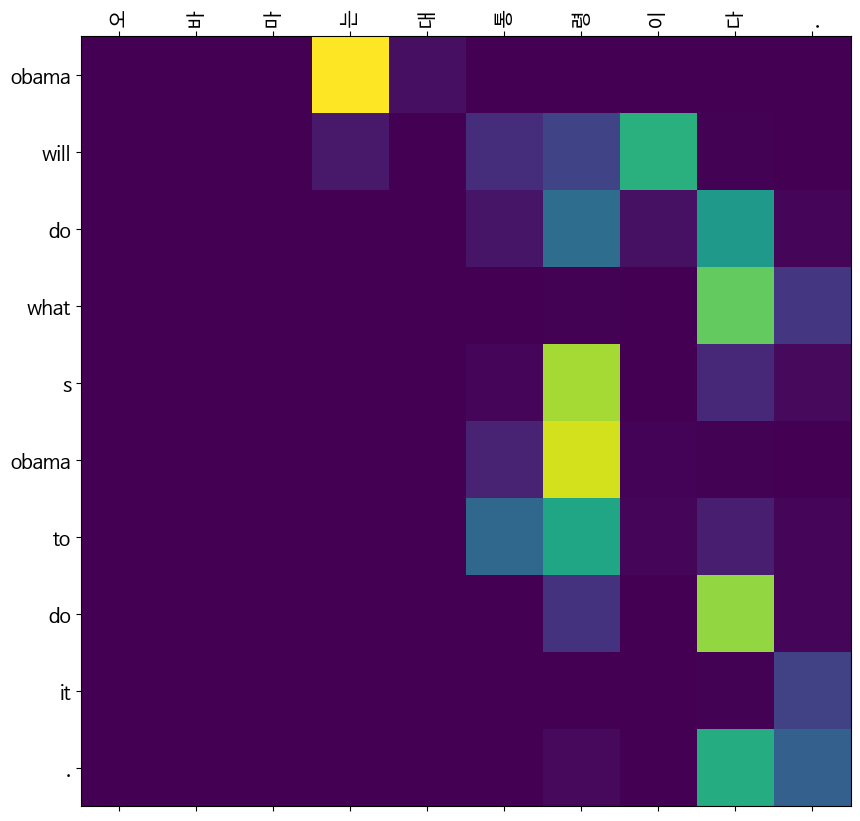

In [45]:
translate("오바마는 대통령이다.", model, max_len=40)


Input: 시민들은 도시 속에 산다.
Predicted translation: the city also had been in .


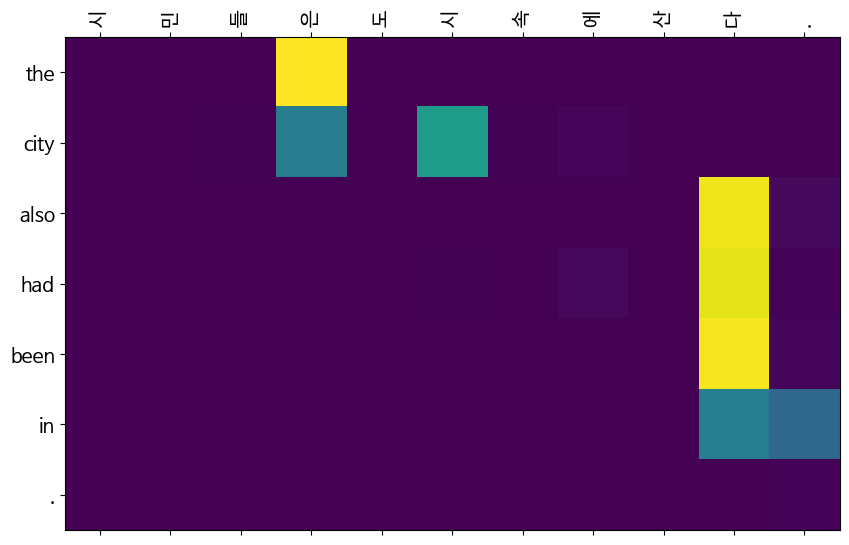

In [46]:
translate("시민들은 도시 속에 산다.", model, max_len=40)


Input: 커피는 필요 없다.
Predicted translation: there are no other other you don t know .


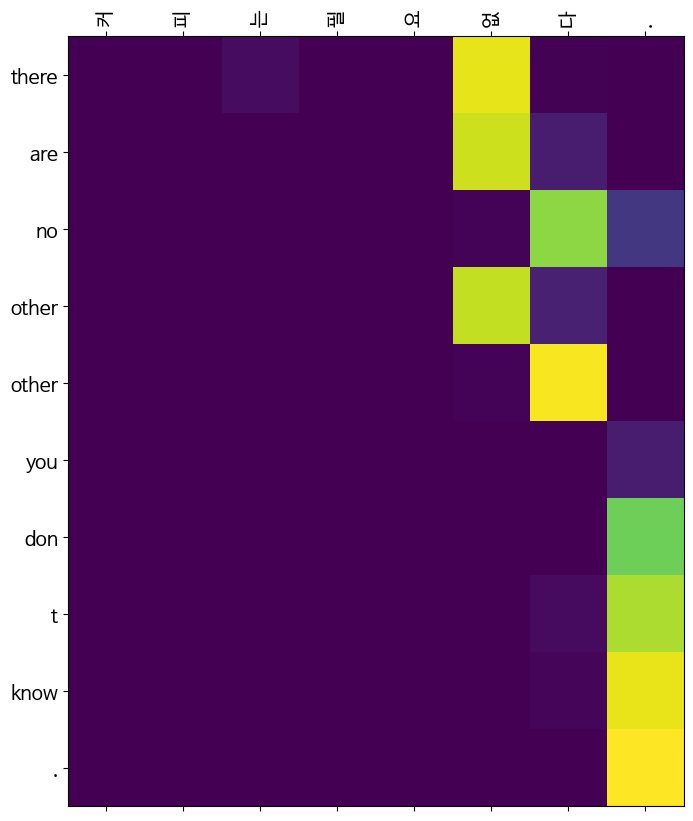

In [47]:
translate("커피는 필요 없다.", model, max_len=40)


Input: 일곱 명의 사망자가 발생했다.
Predicted translation: a dozen people died sunday , when the death toll was .


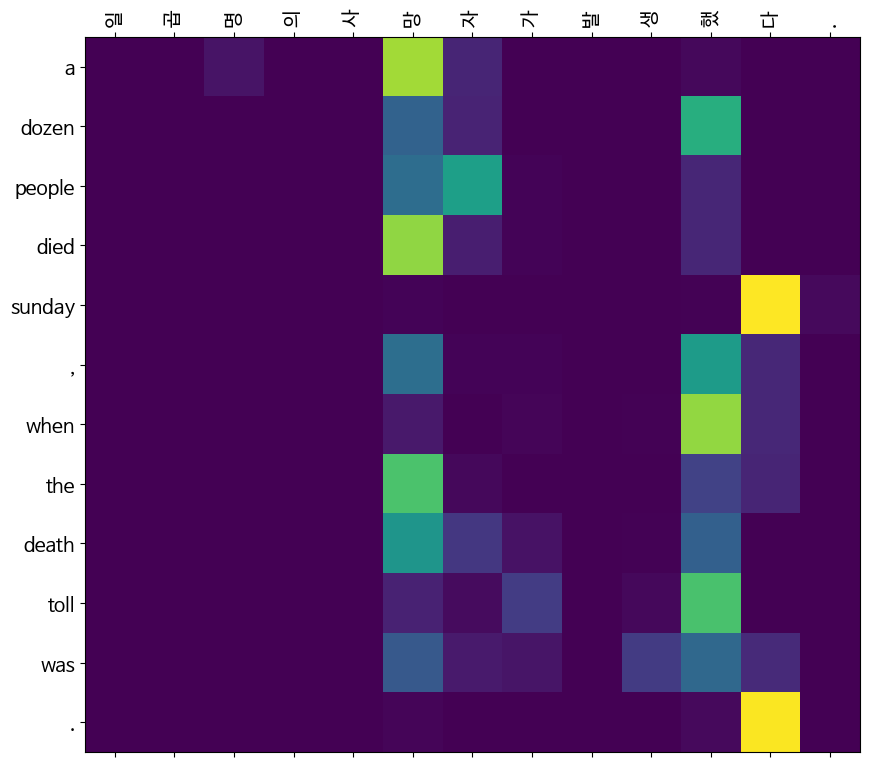

In [48]:
translate("일곱 명의 사망자가 발생했다.", model, max_len=40)


## 회고:
영어-스페인어 실습을 바탕으로 한국어-영어 번역기를 구현해보았다. 코랩에서 작업하다가 다시 주피터 클라우드로 넘어오는 과정에서 자꾸 오류가 나고 <unk>이 출력되기도 했지만 어쩌이찌 해결했다. 하지만 번역 결과는 형편없었다. 그 후 다른 그루의 도움을 받았는데 encoder 부분을 손보라는 조언을 받았다. encoder에 dropout을 넣고, linear state를 통해 차원 수를 맞춰주고, 학습할 때 예측과 정답을 반반 섞어 쓰도록 했다. 하지만 아쉽게도 성능의 향상으로 이어지진 않았다.